In [2]:
import joblib
import pandas as pd
import numpy as np
import shapiq

BINARY_PFS = True
RNA_SEQ_ONLY = True

pfs_dir = "binary" if BINARY_PFS else "three-classes"
rna_suffix = "_rna" if RNA_SEQ_ONLY else ""

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pipeline = joblib.load(f'../saved-models/{pfs_dir}/best_pipeline{rna_suffix}_xgboost.joblib')
x_train = pd.read_csv(f"../dataset/created/{pfs_dir}/x_train{rna_suffix}_xgboost.csv")
x_test = pd.read_csv(f"../dataset/created/{pfs_dir}/x_test{rna_suffix}_xgboost.csv")
y_train = pd.read_csv(f"../dataset/created/{pfs_dir}/y_train{rna_suffix}_xgboost.csv").squeeze()
y_test = pd.read_csv(f"../dataset/created/{pfs_dir}/y_test{rna_suffix}_xgboost.csv").squeeze()

x = pd.concat([x_train, x_test])
y = pd.concat([y_train, y_test])


In [4]:
model = pipeline[-1]

x_scaled = pipeline[:-1].transform(x)   # x -> preprocessed 
x_train_scaled = pipeline[:-1].transform(x_train)

preprocessed_feature_names = pipeline['preprocess'].get_feature_names_out()
feature_names = [
    n.replace('remainder__', '')
     .replace('m_stage__', '')
     .replace('categorical__', '')
     .replace('sex__', '')
     .replace('age__', '')
     .replace('drug_braf__', '')
    for n in pipeline['preprocess'].get_feature_names_out()
]
n_features = len(feature_names)

## Explain a single sample

In [5]:
sample_idx = 10
pred_class = model.predict(x_scaled[sample_idx].reshape(1, -1))[0]
true_class = y.iloc[sample_idx]
print(f"Predicted class: {pred_class}")
print(f"Ground truth class: {true_class}")

Predicted class: 0
Ground truth class: 0


In [6]:
explainer = shapiq.Explainer(
    model=model, 
    # data=x_train_scaled,  # shapiq TreeExplainer does need this
    max_order=2,
    index='k-SII',
    random_state=42
)  

iv = explainer.explain(x_scaled[sample_idx], budget=2**n_features, random_state=42)  # explain for first sample                         
iv.feature_names = feature_names
print(iv)

InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=None,
    n_players=34, baseline_value=3.9020412736372236,
    Top 10 interactions:
        (): 3.9020412736372236
        (np.int64(33),): -0.2200910724917228
        (np.int64(27),): -0.2375170303730214
        (np.int64(21),): -0.25851401197416574
        (np.int64(19),): -0.26809648665445934
        (np.int64(15),): -0.32367877387776856
        (np.int64(16),): -0.3324937068736843
        (np.int64(30),): -0.3584488270361512
        (np.int64(29),): -0.4234713670183248
        (np.int64(32),): -0.5344146675471474
)


In [7]:
print(iv.get_n_order(2).dict_values)


{(np.int64(14), np.int64(23)): -0.0019255175463418796, (np.int64(17), np.int64(28)): -0.0018683639645106671, (np.int64(16), np.int64(29)): -0.012359942765213546, (np.int64(29), np.int64(32)): 0.007938793887939208, (np.int64(17), np.int64(20)): -0.0017943601027479927, (np.int64(17), np.int64(21)): 0.020368285335472386, (np.int64(20), np.int64(21)): -0.0026711956730241723, (np.int64(30), np.int64(32)): 0.05798424766745844, (np.int64(16), np.int64(20)): -0.0017165268218744716, (np.int64(22), np.int64(29)): -0.0015434753454068547, (np.int64(22), np.int64(32)): -0.00805902050886473, (np.int64(14), np.int64(30)): -0.002077385834476494, (np.int64(20), np.int64(33)): -0.0015060878800360945, (np.int64(15), np.int64(29)): -0.00573834689839419, (np.int64(21), np.int64(32)): 0.0020057152048989745, (np.int64(26), np.int64(29)): -0.010447345138479908, (np.int64(15), np.int64(32)): -0.02506543333996538, (np.int64(28), np.int64(30)): -0.0019902170699693184, (np.int64(28), np.int64(32)): 0.021988309586

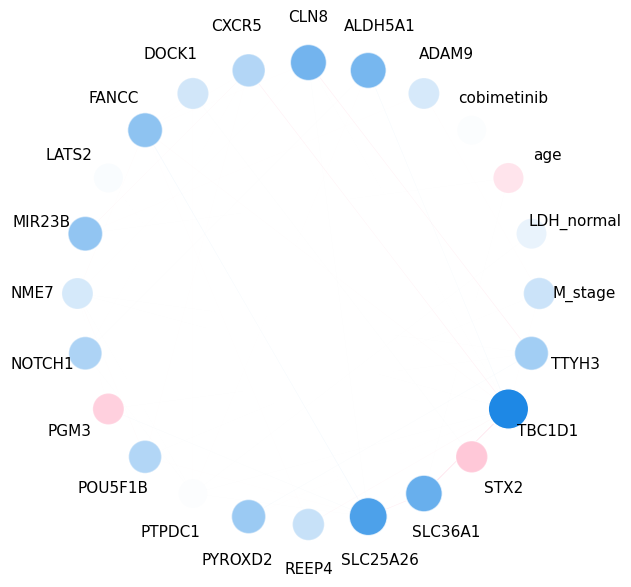

In [8]:
shapiq.network_plot(
    interaction_values=iv,
    feature_names=feature_names,
    # size_factor=3.0,        # scales BOTH nodes and edges up
    # node_size_scaling=0.5,  # then shrink nodes back down
    show=True
)

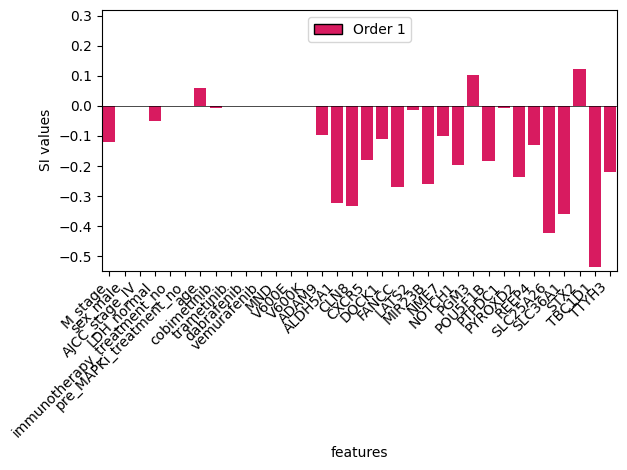

In [9]:
shapiq.stacked_bar_plot(iv.get_n_order(1), feature_names=feature_names, show=True)

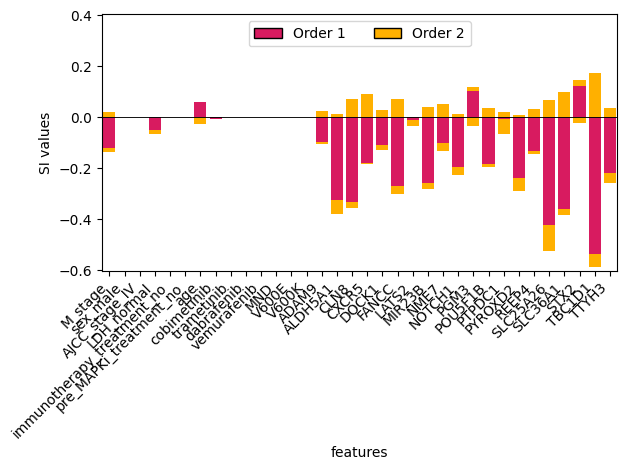

In [10]:
shapiq.stacked_bar_plot(iv, feature_names=feature_names, show=True)

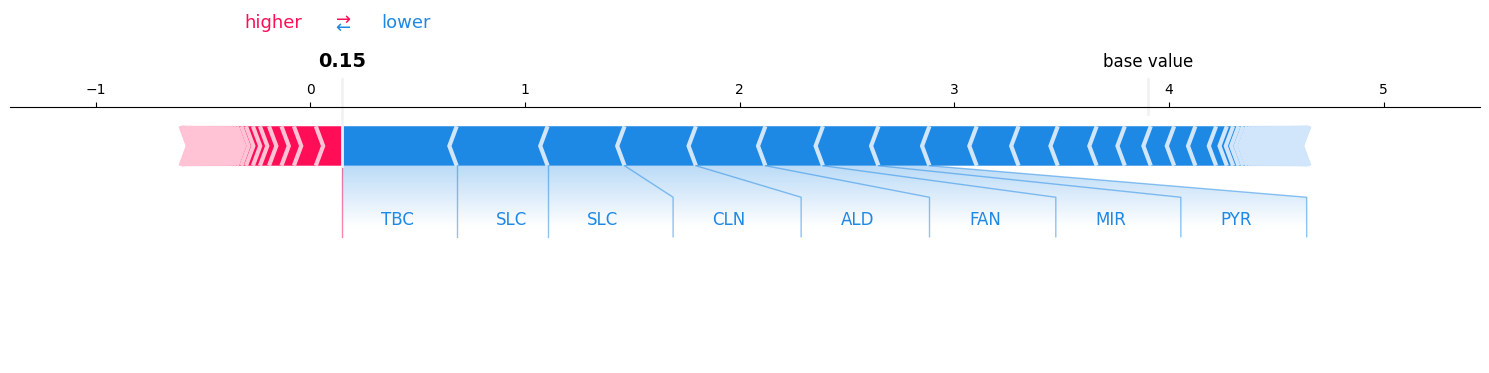

In [11]:
iv.plot_force(feature_names=feature_names, show=True)

## Global

In [12]:
# parallel explanation of multiple samples
ivs = explainer.explain_X(x_scaled, budget=2**n_features, n_jobs=2)
print(f"Computed {len(ivs)} explanations")

Computed 78 explanations


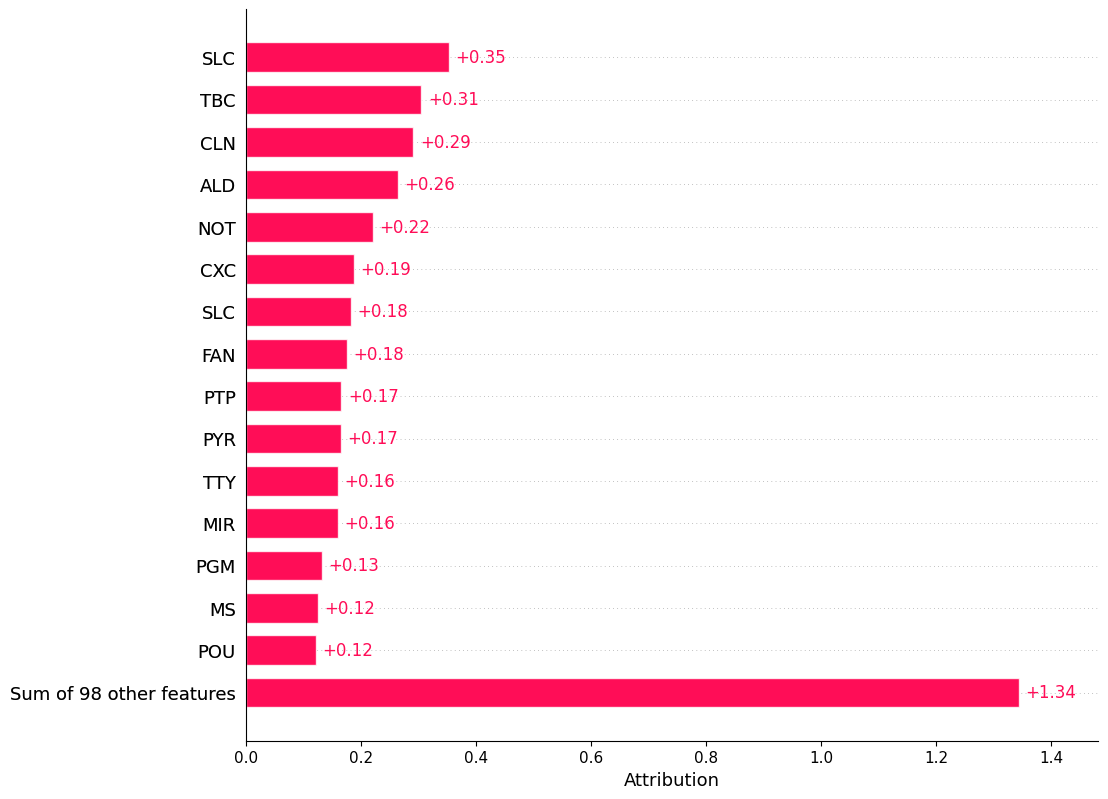

In [13]:
shapiq.bar_plot(ivs, feature_names=feature_names, max_display=15, show=True)

## Aggregated order-2 interactions across all samples

Per-sample order-2 values are tiny and noisy. Aggregate them across the cohort to find feature pairs whose interaction is consistently non-zero (in magnitude and/or sign).

In [14]:
from collections import defaultdict

pair_values = defaultdict(list)
for instance_iv in ivs:
    for pair, value in instance_iv.get_n_order(2).dict_values.items():
        pair_values[pair].append(value)

interaction_df = pd.DataFrame([
    {
        "feature_1": feature_names[pair[0]],
        "feature_2": feature_names[pair[1]],
        "mean_abs": np.abs(values).mean(),
        "mean_signed": np.mean(values),
        "std": np.std(values),
        "consistency": abs(np.mean(values)) / np.abs(values).mean(),  # 1 = always same sign, 0 = cancels out
    }
    for pair, values in pair_values.items()
])

interaction_df.sort_values("mean_abs", ascending=False).head(20)

,feature_1,feature_2,mean_abs,mean_signed,std,consistency
7,SLC36A1,TBC1D1,0.042042,-0.005114,0.049331,0.121643
22,FANCC,SLC25A26,0.021897,0.003062,0.024572,0.139851
61,CLN8,TTYH3,0.021702,0.003727,0.022950,0.171726
40,ALDH5A1,NOTCH1,0.020619,0.003137,0.022202,0.152128
16,ALDH5A1,TBC1D1,0.020391,0.002066,0.022427,0.101299
57,SLC25A26,SLC36A1,0.020345,0.004165,0.024898,0.204699
28,PYROXD2,TTYH3,0.017587,-0.001985,0.019044,0.112886
38,PGM3,SLC25A26,0.016881,0.002389,0.020040,0.141505
31,FANCC,TBC1D1,0.014522,0.004482,0.015337,0.308631
34,CXCR5,TBC1D1,0.014129,0.004112,0.015692,0.291059


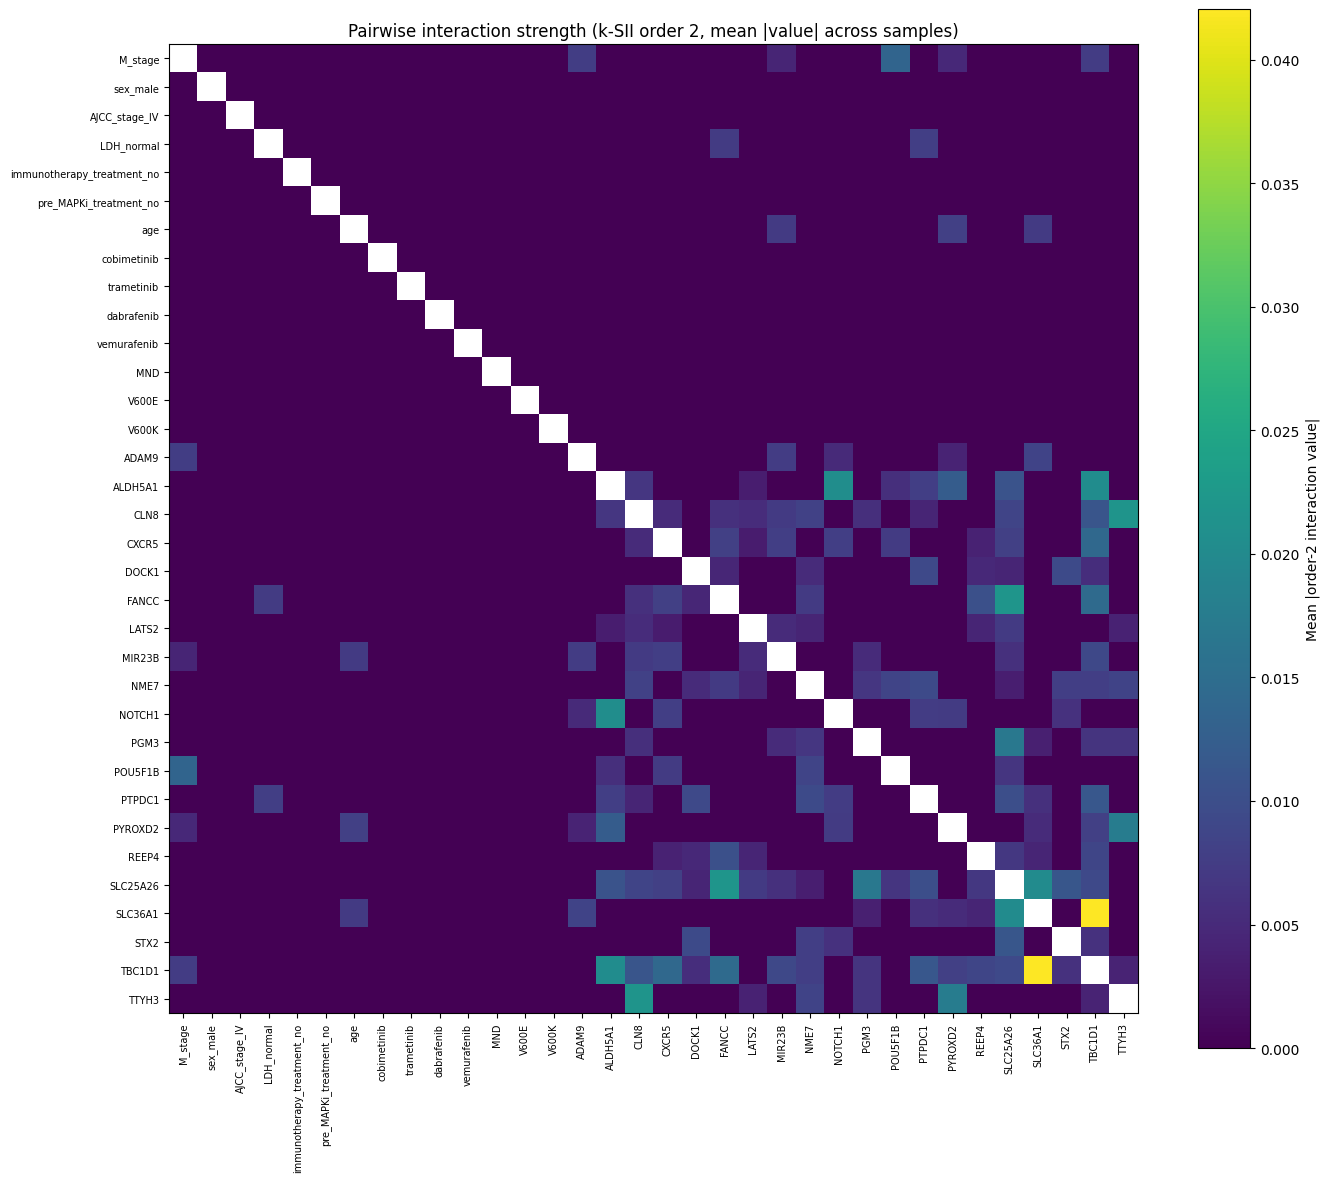

In [ ]:
import matplotlib.pyplot as plt

interaction_matrix = np.zeros((n_features, n_features))
for (i, j), values in pair_values.items():
    val = np.abs(values).mean()
    interaction_matrix[i, j] = val
    interaction_matrix[j, i] = val

np.fill_diagonal(interaction_matrix, np.nan)  # main effects, not interactions

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(interaction_matrix, cmap="viridis")
ax.set_xticks(range(n_features))
ax.set_yticks(range(n_features))
ax.set_xticklabels(feature_names, rotation=90, fontsize=7)
ax.set_yticklabels(feature_names, fontsize=7)
fig.colorbar(im, label="Mean |order-2 interaction value|")
ax.set_title("Pairwise interaction strength (k-SII order 2, mean |value| across samples)")
plt.tight_layout()
plt.show()